# Retail Sales Data Analysis
This case study involves analyzing retail sales data to gain insights into sales performance across different stores and products. The dataset includes the following columns:
- `InvoiceNo`: Invoice number
- `StockCode`: Product code
- `Description`: Product description
- `Quantity`: Quantity of each product (negative values represent returns)
- `InvoiceDate`: Date of the invoice
- `UnitPrice`: Price per unit
- `CustomerID`: ID of the customer
- `Country`: Country of the customer

We will perform the following steps:
1. Importing Libraries and Loading the Dataset
2. Checking for Missing Values
3. Handling Missing Values
4. Identifying Outliers in Quantity
5. Top 5 Products by Quantity Sold
6. Sales by Country
7. Common Purchase Patterns by Country and Month
8. Crosstab of Product Category and Month
9. Average Sales Price by Country and Product
10. Function to Analyze Product Sales
11. Additional Analysis Questions

## 1. Importing Libraries and Loading the Dataset
**Question:** How do we load and preview a dataset in Python?

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
!gdown "1YuFSym955Qsl9DlouoCX41DYgjdEGQNy"

Downloading...
From (original): https://drive.google.com/uc?id=1YuFSym955Qsl9DlouoCX41DYgjdEGQNy
From (redirected): https://drive.google.com/uc?id=1YuFSym955Qsl9DlouoCX41DYgjdEGQNy&confirm=t&uuid=317d8937-6e3a-425d-979b-d83e3375cf2b
To: /content/Online retail dataset.zip
100% 45.4M/45.4M [00:00<00:00, 47.5MB/s]


In [ ]:
!unzip "/content/Online retail dataset.zip"

Archive:  /content/Online retail dataset.zip
  inflating: online_retail_II.xlsx   


In [ ]:
import pandas as pd

# Load the Excel file and read all sheets into a dictionary of DataFrames

dfs = pd.read_excel('online_retail_II.xlsx', sheet_name=None)

# Concatenate all DataFrames
combined_df = pd.concat(dfs.values(), ignore_index=True)

# Save the combined DataFrame to a CSV file
combined_csv_path = "combined_online_retail_data.csv"
combined_df.to_csv(combined_csv_path, index=False)

combined_csv_path


'combined_online_retail_data.csv'

**Insight:**
The dataset contains information about retail transactions, including product details, quantity, price, and customer information.

In [ ]:
len(combined_df.index)

1067371

In [ ]:
combined_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
combined_df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

## 2. Checking for Missing Values
**Question:** Which columns have missing values, and how many missing values are there in each column?

In [ ]:
df = combined_df.copy()

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,1067371.0,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445


In [ ]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Description      4382
Customer ID    243007
dtype: int64

**Insight:**
The 'Description' and 'CustomerID' columns have missing values, with 'CustomerID' having a significant number of missing entries.

## 3. Handling Missing Values
**Question:** How can we handle missing values in the dataset effectively?

In [ ]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [ ]:
# Drop rows with missing 'Description'
df.dropna(subset=['Description'], inplace=True)

df["Customer ID"].astype(str)

# Fill missing 'CustomerID' with a placeholder value
df['Customer ID'].fillna("Unknown", inplace=True)

# Verify no missing values remain
df.isnull().sum()

<ipython-input-12-3658aa2f875a>:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['Customer ID'].fillna("Unknown", inplace=True)


Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [ ]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,object
Country,object


**Insight:**
All missing values in 'Description' were dropped, and 'CustomerID' missing values were filled with "Unknown, ensuring the dataset is now complete.

## 4. Identifying Outliers in Quantity
**Question:** How can we identify and handle outliers in the 'Quantity' column?

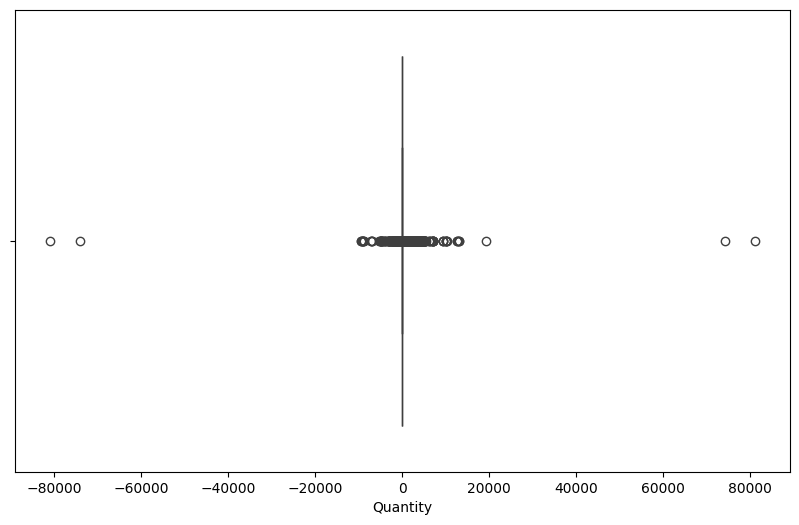

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot to identify outliers in 'Quantity'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Quantity'])
plt.show()



**Insight:**
Outliers in the 'Quantity' column were capped at the 99th percentile, reducing their impact on analysis and ensuring more reliable insights.

In [ ]:
len(df[df["Quantity"]>df['Quantity'].quantile(0.995)]['Quantity'])

4959

In [ ]:
# Handle outliers in 'Quantity' by capping the values
quantity_upper_limit = df['Quantity'].quantile(0.99)

df['Quantity'] = df['Quantity'].apply(lambda x: quantity_upper_limit if x > quantity_upper_limit else x)

In [ ]:
df.describe(exclude=np.number).T

,count,unique,top,freq,mean,min,25%,50%,75%,max
Invoice,1062989.0,49353.0,537434.0,1350.0,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1062989,4950,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN
InvoiceDate,1062989,NaN,NaN,NaN,2011-01-03 07:38:22.446045184,2009-12-01 07:45:00,2010-07-11 10:28:00,2010-12-07 15:31:00,2011-07-22 15:02:00,2011-12-09 12:50:00
Customer ID,1062989,5943,Unknown,238625,NaN,NaN,NaN,NaN,NaN,NaN
Country,1062989,43,United Kingdom,976948,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Top 5 Products by Quantity Sold
**Question:** Identify the top 5 products by the quantity sold.

In [ ]:
df["StockCode"].nunique()

4950

In [ ]:
df["Description"].nunique()

5698

In [ ]:
df["StockCode"].unique()[:5]

array([85048, '79323P', '79323W', 22041, 21232], dtype=object)

In [ ]:
df[df["StockCode"] =='79323W' ]["Description"].unique()[:10]

array([' WHITE CHERRY LIGHTS', 'WHITE CHERRY LIGHTS',
       'Unsaleable, destroyed.'], dtype=object)

5698

In [ ]:
# Groupby 'Description' and calculate total quantity sold
top_products = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(5).reset_index()
top_products

,StockCode,Quantity
0,84077,108545
1,85123A,96066
2,85099B,95739
3,21212,95450
4,22197,89125


**Insight:**
The top 5 products by quantity sold are identified, with "WHITE HANGING HEART T-LIGHT HOLDER" being the most sold product.

In [ ]:
df.columns

## 6. Sales by Country
**Question:** What is the total sales amount for each country?

In [ ]:
# Calculate total sales amount (Quantity * UnitPrice)
df['TotalAmount'] = df['Quantity'] * df['Price']

# Groupby 'Country' and calculate total sales amount
country_sales = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).reset_index()
country_sales.head(5)

,Country,TotalAmount
0,United Kingdom,1.448715e+07
1,EIRE,5.340505e+05
2,Germany,4.112601e+05
3,Netherlands,4.089573e+05
4,France,3.087419e+05


**Insight:**
The total sales amount is highest for the United Kingdom, followed by the Netherlands and Ireland.

In [ ]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalAmount'],
      dtype='object')

## 7. Common Purchase Patterns by Country and Month
**Question:** What are the common purchase patterns by country and month?

In [ ]:
# Extract month from 'InvoiceDate'
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month

# Groupby 'Country' and 'Month' to calculate total sales amount
monthly_sales = df.groupby(['Country', 'Month'])['TotalAmount'].sum().unstack().fillna(0)
monthly_sales.head()

Month,1,2,3,4,5,6,7,8,9,10,11,12
Country,,,,,,,,,,,,
Australia,7255.15,12585.09,14087.72,964.35,11577.57,23461.73,3895.03,16284.60,3867.36,16811.40,18446.65,1658.10
Austria,0.00,1637.22,2330.37,2069.32,1829.07,243.90,1191.95,2559.23,1589.12,2280.48,4203.08,2938.58
Bahrain,-205.74,439.85,506.30,0.00,1134.36,463.28,0.00,0.00,0.00,317.76,0.00,205.74
Belgium,2762.28,3861.67,4237.60,4503.29,2811.95,7803.36,4332.81,5249.74,5359.08,7127.10,11407.69,3962.64
Bermuda,0.00,0.00,811.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


**Insight:**
The purchase patterns vary by country and month, with different peaks observed in different countries.

## 8. Crosstab of Product Category and Month
**Question:** What is the distribution of product categories across different months?

In [ ]:
# Create a crosstab of 'Description' and 'Month'
product_month_crosstab = pd.crosstab(df['Description'], df['Month'])
product_month_crosstab

Month,1,2,3,4,5,6,7,8,9,10,11,12
Description,,,,,,,,,,,,
20713,0,0,0,0,0,0,0,0,0,1,0,0
21494,0,0,0,0,0,0,0,0,0,0,0,1
22467,0,0,0,0,0,0,1,0,0,0,0,0
22719,0,0,0,0,0,0,1,0,0,0,0,0
DOORMAT UNION JACK GUNS AND ROSES,56,3,3,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
wrongly marked carton 22804,0,0,0,0,0,0,0,0,0,0,1,0
wrongly marked. 23343 in box,0,0,0,0,0,0,1,0,0,0,0,0
wrongly sold (22719) barcode,0,0,1,0,0,0,0,0,0,0,0,0


**Insight:**
The distribution of product sales varies across different months, indicating seasonal trends in product sales.

## 9. Average Sales Price by Country and Product
**Question:** What is the average sales price by country and product?

In [ ]:
# Groupby 'Country' and 'Description' to calculate average unit price
average_price = df.groupby(['Country', 'Description'])['Price'].mean().unstack().fillna(0)
average_price.head()

Description,20713,21494,22467,22719,DOORMAT UNION JACK GUNS AND ROSES,3 STRIPEY MICE FELTCRAFT,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,ANIMAL STICKERS,BLACK PIRATE TREASURE CHEST,...,wrongly coded 20713,wrongly coded 23343,wrongly coded-23343,wrongly marked,wrongly marked 23343,wrongly marked carton 22804,wrongly marked. 23343 in box,wrongly sold (22719) barcode,wrongly sold as sets,wrongly sold sets
Country,,,,,,,,,,,,,,,,,,,,,
Australia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Austria,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bahrain,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Belgium,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bermuda,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Insight:**
The average sales price varies by country and product, providing insights into pricing strategies and customer preferences.

## 10. Function to Analyze Product Sales
**Question:** Create a function to analyze sales performance of a specific product (total sales amount, quantity sold, etc.) across all countries.

In [ ]:
def analyze_product_sales(product_description, df):

    # Filter data for the product
    product_data = df[df['Description'] == product_description]

    # Calculate total sales amount and quantity sold
    total_sales = product_data['TotalAmount'].sum()
    total_quantity = product_data['Quantity'].sum()

    # Calculate sales performance across all countries
    country_performance = product_data.groupby('Country')[['TotalAmount', 'Quantity']].sum().reset_index()

    return {
        'Total Sales Amount': total_sales,
        'Total Quantity Sold': total_quantity,
        'Sales Performance by Country': country_performance
    }

# Example usage
product_performance = analyze_product_sales(" WHITE CHERRY LIGHTS", df)
product_performance

{'Total Sales Amount': 12108.86,
 'Total Quantity Sold': 2010,
 'Sales Performance by Country':           Country  TotalAmount  Quantity
 0         Denmark       130.80        24
 1            EIRE       288.60        52
 2           Spain       157.80        28
 3  United Kingdom     11531.66      1906}

**Insight:**
The function provides a detailed analysis of a specific product's sales performance, including total sales amount, quantity sold, and performance across different countries.

# Additional Analysis Questions

## 11. Monthly Sales Trend by Country
**Question:** How can you find the total sales amount for each country in each month?

In [ ]:
# Groupby 'Country' and 'Month' to calculate total sales amount
monthly_sales_trend = df.groupby(['Country', 'Month'])['TotalAmount'].sum().unstack().fillna(0).reset_index()
monthly_sales_trend.head()

Month,Country,1,2,3,4,5,6,7,8,9,10,11,12
0,Australia,9017.71,15657.13,17484.68,964.35,14941.21,28354.05,5401.19,22665.20,5817.56,20139.68,25013.81,1672.50
1,Austria,0.00,1637.22,2633.25,2069.32,1831.47,243.90,1191.95,2559.23,1589.12,2280.48,4203.08,2938.58
2,Bahrain,-205.74,439.85,506.30,0.00,1134.36,463.28,0.00,0.00,0.00,317.76,0.00,205.74
3,Belgium,2778.12,3861.67,4237.60,4503.29,2811.95,7808.56,4387.85,5249.74,5387.88,7127.10,11407.69,4013.04
4,Bermuda,0.00,0.00,1253.14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


**Insight:**
This helps in understanding the monthly sales trends for each country.

## 12. Average Quantity Sold per Invoice by Country
**Question:** What is the average quantity of products sold per invoice in each country?

In [ ]:
# Groupby 'Country' and 'InvoiceNo' to calculate total quantity per invoice
country_invoice_quantity = df.groupby(['Country', 'Invoice'])['Quantity'].sum().reset_index()

# Groupby 'Country' to calculate the average quantity per invoice
avg_quantity_per_invoice = country_invoice_quantity.groupby('Country')['Quantity'].mean().reset_index()
avg_quantity_per_invoice.head()

,Country,Quantity
0,Australia,600.017094
1,Austria,213.137255
2,Bahrain,106.250000
3,Belgium,189.661202
4,Bermuda,694.000000


**Insight:**
This provides insights into the average size of orders in different countries.

## 13. Popular Product Categories by Country
**Question:** Which product categories are the most popular in each country based on quantity sold?

In [ ]:
# Groupby 'Country' and 'Description' to calculate total quantity sold
country_product_quantity = df.groupby(['Country', 'Description'])['Quantity'].sum().reset_index()

# Find the most popular product category in each country
popular_products = country_product_quantity.loc[country_product_quantity.groupby('Country')['Quantity'].idxmax()].reset_index(drop=True)
popular_products.head()

,Country,Description,Quantity
0,Australia,RED TOADSTOOL LED NIGHT LIGHT,928.0
1,Austria,ASSORTED COLOUR BIRD ORNAMENT,136.0
2,Bahrain,WHITE TALL PORCELAIN T-LIGHT HOLDER,102.0
3,Belgium,PACK OF 60 SPACEBOY CAKE CASES,584.0
4,Bermuda,BOYS ALPHABET IRON ON PATCHES,100.0


**Insight:**
This identifies the top-selling product categories in each country.

## 14. Monthly Sales Performance of Top 5 Products
**Question:** How does the monthly sales performance vary for the top 5 products?

In [ ]:
top_products

Index(['WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT',
       'ASSORTED COLOUR BIRD ORNAMENT', 'WORLD WAR 2 GLIDERS ASSTD DESIGNS',
       '60 TEATIME FAIRY CAKE CASES'],
      dtype='object', name='Description')

In [ ]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

Description
WHITE HANGING HEART T-LIGHT HOLDER    73417.0
JUMBO BAG RED RETROSPOT               61984.0
ASSORTED COLOUR BIRD ORNAMENT         59773.0
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53665.0
60 TEATIME FAIRY CAKE CASES           41370.0
                                       ...   
printing smudges/thrown away         -19200.0
given away                           -20000.0
?                                    -36741.0
MEDIUM CERAMIC TOP STORAGE JAR       -70948.0
PAPER CRAFT , LITTLE BIRDIE          -80895.0
Name: Quantity, Length: 5698, dtype: float64

In [ ]:
# Find the top 5 products by total quantity sold
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5).index

# Filter data for the top 5 products
top_products_data = df[df['Description'].isin(top_products)]

# Pivot table to show monthly sales performance of top 5 products
monthly_sales_performance = top_products_data.pivot_table(values='TotalAmount', index='Month', columns='Description', aggfunc='sum').fillna(0)
monthly_sales_performance

Description,60 TEATIME FAIRY CAKE CASES,ASSORTED COLOUR BIRD ORNAMENT,JUMBO BAG RED RETROSPOT,WHITE HANGING HEART T-LIGHT HOLDER,WORLD WAR 2 GLIDERS ASSTD DESIGNS
Month,,,,,
1,1576.79,4859.20,4043.85,18178.59,485.64
2,1651.58,4826.90,4953.64,12745.13,726.07
3,2103.80,8288.09,6431.98,16938.10,922.79
4,1935.58,7983.69,4526.92,9820.75,1000.61
5,2010.72,7830.11,8540.25,19421.14,863.99
6,1760.37,5270.94,12959.78,13879.74,1187.84
7,1638.27,7359.81,11507.33,15292.50,1112.33
8,1694.68,7683.39,11876.78,14417.49,964.08
9,2116.79,9582.69,18939.24,17383.08,1491.98


**Insight:**
This allows analysis of how sales of the top 5 products fluctuate over different months.

In [ ]:
df.groupby("Description")["Quantity"].sum().sort_values

## 15. Total Revenue by Product Category and Country
**Question:** What is the total revenue generated by each product category in each country?

In [ ]:
# Groupby 'Country' and 'Description' to calculate total revenue
revenue_by_category_country = df.groupby(['Country', 'Description'])['TotalAmount'].sum().unstack().fillna(0)
revenue_by_category_country.head()

Description,20713,21494,22467,22719,DOORMAT UNION JACK GUNS AND ROSES,3 STRIPEY MICE FELTCRAFT,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,ANIMAL STICKERS,BLACK PIRATE TREASURE CHEST,...,wrongly coded 20713,wrongly coded 23343,wrongly coded-23343,wrongly marked,wrongly marked 23343,wrongly marked carton 22804,wrongly marked. 23343 in box,wrongly sold (22719) barcode,wrongly sold as sets,wrongly sold sets
Country,,,,,,,,,,,,,,,,,,,,,
Australia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Austria,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bahrain,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Belgium,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bermuda,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Insight:**
This shows the revenue distribution across different product categories and countries.

In [ ]:
df[df["Customer ID"]==13085]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,12
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,12
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,12
...,...,...,...,...,...,...,...,...,...,...
775536,558996,22617,BAKING SET SPACEBOY DESIGN,3.0,2011-07-05 12:11:00,4.95,13085.0,United Kingdom,14.85,7
775537,558996,22138,BAKING SET 9 PIECE RETROSPOT,3.0,2011-07-05 12:11:00,4.95,13085.0,United Kingdom,14.85,7
775538,558996,20749,ASSORTED COLOUR MINI CASES,2.0,2011-07-05 12:11:00,7.95,13085.0,United Kingdom,15.90,7
775539,558996,22193,RED DINER WALL CLOCK,2.0,2011-07-05 12:11:00,8.50,13085.0,United Kingdom,17.00,7


In [ ]:
df.groupby("Customer ID")["Invoice"].count()

Customer ID
12346.0        48
12347.0       253
12348.0        51
12349.0       180
12350.0        17
            ...  
18284.0        29
18285.0        12
18286.0        70
18287.0       156
Unknown    238625
Name: Invoice, Length: 5943, dtype: int64

## 16. Customer Purchase Frequency
**Question:** How frequently do customers make purchases, and what is the average purchase amount?

In [ ]:
# Groupby 'CustomerID' to calculate the number of purchases and average purchase amount
customer_purchase_freq = df.groupby('Customer ID').agg({
                                                        'Invoice': 'nunique',
                                                        'TotalAmount': 'mean'
                                                        }).reset_index()
customer_purchase_freq.columns = ['Customer ID', 'PurchaseFrequency', 'AvgPurchaseAmount']
customer_purchase_freq.sort_values(by="PurchaseFrequency", ascending=False).reset_index(drop = True)

,Customer ID,PurchaseFrequency,AvgPurchaseAmount
0,Unknown,4477,10.578911
1,14911.0,510,22.768581
2,12748.0,365,6.625800
3,17841.0,289,5.303962
4,15311.0,270,23.217479
...,...,...,...
5938,12486.0,1,21.168980
5939,14941.0,1,26.014286
5940,17066.0,1,12.685556
5941,14943.0,1,21.524000


In [ ]:
customer_purchase_freq.sort_values(by="AvgPurchaseAmount", ascending=False).reset_index(drop = True)

,Customer ID,PurchaseFrequency,AvgPurchaseAmount
0,17846.0,1,2033.10
1,12737.0,2,1855.25
2,13205.0,1,1095.00
3,17291.0,1,550.80
4,15929.0,1,495.00
...,...,...,...
5938,16151.0,1,-4217.59
5939,16981.0,1,-4620.86
5940,15849.0,1,-5876.34
5941,17399.0,1,-25111.09


from matplotlib import pyplot as plt
_df_0['PurchaseFrequency'].plot(kind='hist', bins=20, title='PurchaseFrequency')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['AvgPurchaseAmount'].plot(kind='hist', bins=20, title='AvgPurchaseAmount')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='PurchaseFrequency', y='AvgPurchaseAmount', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['PurchaseFrequency'].plot(kind='line', figsize=(8, 4), title='PurchaseFrequency')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_4['AvgPurchaseAmount'].plot(kind='line', figsize=(8, 4), title='AvgPurchaseAmount')
plt.gca().spines[['top', 'right']].set_visible(False)

**Insight:**
This provides insights into customer behavior in terms of purchase frequency and average spending.

## 17. Sales Contribution by Product Category
**Question:** What is the contribution of each product category to the total sales amount?

In [ ]:
[category_sales["TotalAmount"],df['TotalAmount'].sum()], category_sales["TotalAmount"].sum()

([0       1.700913e+07
  1       1.700913e+07
  2       1.700913e+07
  3       1.700913e+07
  4       1.054566e+09
              ...     
  5693    1.700913e+07
  5694    1.700913e+07
  5695    1.700913e+07
  5696    1.700913e+07
  5697    1.700913e+07
  Name: TotalAmount, Length: 5698, dtype: float64,
  18080515993355.75],
 18080515993355.703)

In [ ]:
# Groupby 'Description' to calculate total sales amount
category_sales_con = df.groupby('Description')['TotalAmount'].sum().reset_index()

# Calculate the percentage contribution of each category
category_sales_con['SalesContribution'] = (category_sales_con['TotalAmount']) / (df['TotalAmount'].sum())*100
category_sales_con.sort_values(by='SalesContribution', ascending=False).head(10)

,Description,TotalAmount,SalesContribution
5266,WHITE HANGING HEART T-LIGHT HOLDER,1.006600e+11,0.556732
3915,REGENCY CAKESTAND 3 TIER,7.504427e+10,0.415056
2508,JUMBO BAG RED RETROSPOT,5.900467e+10,0.326344
328,ASSORTED COLOUR BIRD ORNAMENT,5.031300e+10,0.278272
3294,PARTY BUNTING,4.703024e+10,0.260116
4816,STRAWBERRY CERAMIC TRINKET BOX,4.444485e+10,0.245816
2733,LUNCH BAG BLACK SKULL.,4.301608e+10,0.237914
2522,JUMBO STORAGE BAG SUKI,4.140022e+10,0.228977
2314,HEART OF WICKER SMALL,3.944417e+10,0.218158
2520,JUMBO SHOPPER VINTAGE RED PAISLEY,3.906997e+10,0.216089


**Insight:**
This helps identify the most significant product categories in terms of revenue contribution.

## 18. High-Value Customers
**Question:** Who are the top 10 customers based on total purchase amount?

In [ ]:
# Groupby 'CustomerID' to calculate total purchase amount
customer_total_purchase = df.groupby('Customer ID')['TotalAmount'].sum().sort_values(ascending=False).head(10).reset_index()
customer_total_purchase

,Customer ID,TotalAmount
0,Unknown,4.058803e+12
1,17841.0,2.227685e+11
2,14911.0,1.975270e+11
3,12748.0,1.242857e+11
4,14606.0,1.141142e+11
5,14096.0,8.722281e+10
6,15311.0,8.023206e+10
7,14156.0,7.024770e+10
8,14646.0,6.616551e+10
9,13089.0,5.847738e+10


**Insight:**
This identifies the top 10 customers who contribute the most to the total sales amount.

In [ ]:
df['TotalAmount'].sort_values(ascending=True).head(5)

0         1.700913e+07
712340    1.700913e+07
712341    1.700913e+07
712342    1.700913e+07
712343    1.700913e+07
Name: TotalAmount, dtype: float64

## 19. Sales Performance during Holidays
**Question:** How does sales performance change during holiday seasons?

In [ ]:
# Create a holiday flag based on 'InvoiceDate'
df['IsHoliday'] = df['InvoiceDate'].dt.month.isin([11, 12])

# Groupby 'IsHoliday' to calculate total sales amount
holiday_sales_performance = df.groupby('IsHoliday')['TotalAmount'].sum().reset_index()
holiday_sales_performance.columns = ['IsHoliday', 'TotalSales']
holiday_sales_performance

**Insight:**
This shows the increase in sales during the holiday seasons (November and December).

## 20. Return Rate by Product Category
**Question:** What is the return rate for each product category?

In [ ]:
# Groupby 'Description' to calculate total quantity and returns (negative quantities)
returns_by_category = df.groupby('Description').agg({
    'Quantity': [lambda x: x[x >= 0].sum(),'sum', lambda x: x[x < 0].sum(),]
}).reset_index()
returns_by_category.columns = ['Description', "TotalQuantity","Net Sold", 'ReturnedQuantity', ]

returns_by_category.sort_values(by = "TotalQuantity",ascending=False)

,Description,TotalQuantity,Net Sold,ReturnedQuantity
5266,WHITE HANGING HEART T-LIGHT HOLDER,77055.0,73417.0,-3638.0
2508,JUMBO BAG RED RETROSPOT,63179.0,61984.0,-1195.0
328,ASSORTED COLOUR BIRD ORNAMENT,60284.0,59773.0,-511.0
5388,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55369.0,53665.0,-1704.0
168,60 TEATIME FAIRY CAKE CASES,41720.0,41370.0,-350.0
...,...,...,...,...
5520,bad quality,0.0,-76.0,-76.0
5521,barcode problem,0.0,-230.0,-230.0
5522,broken,0.0,-85.0,-85.0
5523,broken glass,0.0,-53.0,-53.0


In [ ]:
returns_by_category["Return Rate"] = returns_by_category["ReturnedQuantity"]/returns_by_category["TotalQuantity"]
returns_by_category.sort_values(by = "ReturnedQuantity", ascending = True)

/usr/local/lib/python3.10/dist-packages/pandas/core/nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Description,TotalQuantity,Net Sold,ReturnedQuantity,Return Rate
3268,"PAPER CRAFT , LITTLE BIRDIE",100.0,-80895.0,-80995.0,-809.950000
2820,MEDIUM CERAMIC TOP STORAGE JAR,3546.0,-70948.0,-74494.0,-21.007896
180,?,900.0,-36741.0,-37641.0,-41.823333
5580,given away,0.0,-20000.0,-20000.0,-inf
5615,printing smudges/thrown away,0.0,-19200.0,-19200.0,-inf
...,...,...,...,...,...
2791,MAGIC SLATE LEAP FROG,96.0,96.0,0.0,0.000000
2792,MAGIC SLATE SPACEBOY,288.0,288.0,0.0,0.000000
2804,MANHATTAN CANVAS ART PICTURE,20.0,20.0,0.0,0.000000
2782,MAGIC GARDEN MOUNT FUJI,159.0,159.0,0.0,0.000000


**Insight:**
This identifies product categories with the highest return rates, helping to understand customer dissatisfaction.